In [2]:
import glob
import os

import time
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import seaborn as sns
import holidays

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

import rasterio
import math
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point
from shapely.ops import transform
from pyproj import Transformer

import warnings
warnings.filterwarnings("ignore")


/Users/ponddie/miniconda3/envs/llm_py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# CONFIG

In [3]:
BASE_DIR              = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()

PATH_EXTRA_DATA       = os.path.join(BASE_DIR, "../../data/extra/")
PATH_TRAFFIC          = os.path.join(BASE_DIR, "../../data/traffic/")
FILEPATH_RICH         = os.path.join(BASE_DIR, "../../data/richtingen.csv")
FILEPATH_SITE         = os.path.join(BASE_DIR, "../../data/sites.csv")
FILEPATH_INFRA        = os.path.join(BASE_DIR, "../andy/output/sites_enriched_clean.csv")

FILEPATH_POP_TIF      = PATH_EXTRA_DATA + "bel_pop_2025_CN_100m_R2025A_v1.tif"
FILEPATH_WEATHER      = PATH_EXTRA_DATA + "site_id_weather_output_new.csv"

TRAFFIC_COLS  = ['site_id', 'direction', 'type', 'from', 'to', 'count']
RICH_COLS     = ['site_id', 'direction', 'name']
SITE_COLS     = ['site_id', 'site_nr', 'longtitude', 'latitude', 'name', 'domain', 'road_nbr','district_nbr', 'municipality', 'interval', 'date_installed']

# FUNCTION

In [4]:
######## FEATURE ENGINEERING ########
def compute_neighbor_traffic_lag_hour_features(df_traffic, df_site):
    RADII_M = [200,500,1000,2000]
    RADII_KM = [r / 1000 for r in RADII_M]   # [0.2, 0.5, 1.0, 2.0]

    sites = df_site.copy()
    sites = sites[["site_id", "latitude", "longtitude"]].drop_duplicates("site_id").copy()
    sites = sites.sort_values("site_id").reset_index(drop=True)

    ids = sites["site_id"].to_numpy()
    lat = sites["latitude"].to_numpy()
    lon = sites["longtitude"].to_numpy()

    # Haversine for all pairs (vectorized)
    R = 6371.0
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    dlat = lat_rad[:, None] - lat_rad[None, :]
    dlon = lon_rad[:, None] - lon_rad[None, :]
    a = (np.sin(dlat / 2) ** 2
        + np.cos(lat_rad)[:, None] * np.cos(lat_rad)[None, :] * np.sin(dlon / 2) ** 2)
    dist = 2 * R * np.arcsin(np.sqrt(a))

    # Fill diagonal with infinity so that sites don't consider themselves as neighbors
    np.fill_diagonal(dist, np.inf)

    dist_df = pd.DataFrame(dist, index=ids, columns=ids)

    # radius_maps[radius_m][site_id] = [list site within that radius]
    radius_maps = {r_m: {} for r_m in RADII_M}
    for site in ids:
        ordered = dist_df.loc[site].sort_values()
        for r_m, r_km in zip(RADII_M, RADII_KM):
            radius_maps[r_m][site] = ordered[ordered <= r_km].index.tolist()


    df_traffic_cleaned = df_traffic.copy()
    df_traffic_cleaned = df_traffic_cleaned[df_traffic_cleaned["type"] == "FIETSERS"]
    df_traffic_cleaned['count'] = df_traffic_cleaned['count'].fillna(0)
    df_traffic_cleaned["site_id"]   = df_traffic_cleaned["site_id"].astype("int32")
    df_traffic_cleaned["from"] = pd.to_datetime(df_traffic_cleaned["from"])
    df_traffic_cleaned["datehour"] = pd.to_datetime(df_traffic_cleaned["from"]).dt.floor("h")

    df_traffic_hourly = (
        df_traffic_cleaned
        .groupby(["site_id", "datehour"], as_index=False)["count"]
        .sum()
        .rename(columns={'count':'traffic_total'})
        .reset_index(drop=True)
    )
    traffic_wide = df_traffic_hourly.pivot_table(index="datehour",columns="site_id",values="traffic_total",aggfunc="sum").sort_index()

    lag_dfs = []
    for LAG in [1, 24, 168]:
        traffic_wide_lag = traffic_wide.shift(LAG)
        nan_template = pd.Series(np.nan, index=traffic_wide_lag.index)
        parts = []
        for site in ids:
            row_dict = {"site_id": site, "datehour": traffic_wide_lag.index}
            for r_m in RADII_M:
                rad_cols = [s for s in radius_maps[r_m][site] if s in traffic_wide_lag.columns]
                prefix = f"nb_r{r_m}m_lag{LAG}h"
                if rad_cols:
                    sub = traffic_wide_lag[rad_cols]
                    row_dict[f"{prefix}_mean"] = sub.mean(axis=1).values
                    row_dict[f"{prefix}_max"]  = sub.max(axis=1).values
                    row_dict[f"{prefix}_sum"]  = sub.sum(axis=1).values
                    row_dict[f"{prefix}_std"]  = sub.std(axis=1).values
                else:
                    for stat in ("mean", "max", "sum", "std"):
                        row_dict[f"{prefix}_{stat}"] = nan_template.values
            parts.append(pd.DataFrame(row_dict))
        lag_dfs.append(pd.concat(parts, ignore_index=True))

    df_fts_neighbor_lag = lag_dfs[0]
    for df_lag in lag_dfs[1:]:
        df_fts_neighbor_lag = df_fts_neighbor_lag.merge(
            df_lag.drop(columns=["site_id", "datehour"], errors="ignore")
            if False else df_lag,  # merge full second df
            on=["site_id", "datehour"],
            how="outer",
        )
    df_fts_neighbor_lag.columns = [col.replace('168h', '7d') for col in df_fts_neighbor_lag.columns]
    df_fts_neighbor_lag = df_fts_neighbor_lag[['site_id','datehour'] + [x for x in df_fts_neighbor_lag if x.startswith('nb')]]
    df_fts_neighbor_lag = df_fts_neighbor_lag.loc[:, df_fts_neighbor_lag.isna().mean() <= 0.7]

    return df_fts_neighbor_lag

def compute_neighbor_traffic_lag_15m_features(df_traffic, df_site):
    RADII_M = [200,500,1000,2000]
    RADII_KM = [r / 1000 for r in RADII_M]

    sites = df_site.copy()
    sites = sites[["site_id", "latitude", "longtitude"]].drop_duplicates("site_id").copy()
    sites = sites.sort_values("site_id").reset_index(drop=True)

    ids = sites["site_id"].to_numpy()
    lat = sites["latitude"].to_numpy()
    lon = sites["longtitude"].to_numpy()

    # Haversine for all pairs (vectorized)
    R = 6371.0
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    dlat = lat_rad[:, None] - lat_rad[None, :]
    dlon = lon_rad[:, None] - lon_rad[None, :]
    a = (np.sin(dlat / 2) ** 2
        + np.cos(lat_rad)[:, None] * np.cos(lat_rad)[None, :] * np.sin(dlon / 2) ** 2)
    dist = 2 * R * np.arcsin(np.sqrt(a))

    # Fill diagonal with infinity so that sites don't consider themselves as neighbors
    np.fill_diagonal(dist, np.inf)
    dist_df = pd.DataFrame(dist, index=ids, columns=ids)

    # radius_maps[radius_m][site_id] = [list site within that radius]
    radius_maps = {r_m: {} for r_m in RADII_M}
    for site in ids:
        ordered = dist_df.loc[site].sort_values()
        for r_m, r_km in zip(RADII_M, RADII_KM):
            radius_maps[r_m][site] = ordered[ordered <= r_km].index.tolist()


    df_traffic_cleaned = df_traffic.copy()
    df_traffic_cleaned = df_traffic_cleaned[df_traffic_cleaned["type"] == "FIETSERS"]
    df_traffic_cleaned['count'] = df_traffic_cleaned['count'].fillna(0)
    df_traffic_cleaned["site_id"]   = df_traffic_cleaned["site_id"].astype("int32")
    df_traffic_cleaned["from"] = pd.to_datetime(df_traffic_cleaned["from"])
    df_traffic_cleaned["datehour"] = pd.to_datetime(df_traffic_cleaned["from"]).dt.floor("h")


    # Step 1: 15-min FIETSERS traffic, summed across directions 
    df_traffic_fiets_15min = (
        df_traffic_cleaned
        .groupby(["site_id", "from"], as_index=False)["count"]
        .sum()
        .rename(columns={"count": "total_fiets_15min"})
    )

    # Step 2: Wide matrix (rows = 15-min timestamp, cols = site_id)
    traffic_wide_15min = df_traffic_fiets_15min.pivot_table(
        index="from",
        columns="site_id",
        values="total_fiets_15min",
        aggfunc="sum",
    ).sort_index()
    traffic_wide_15min.index.name = "ts"

    # Step 3: Shift by 1 period (15 min) → previous 15-min traffic 
    # Row at ts=T in shifted table = original traffic at ts=(T-15min)
    traffic_wide_15min_shifted = traffic_wide_15min.shift(1)

    # Step 4: Keep only on-the-hour rows to align with datehour 
    # Row at ts=14:00 (minute==0) after shift = traffic from 13:45-14:00
    traffic_wide_prev15 = traffic_wide_15min_shifted[
        traffic_wide_15min_shifted.index.minute == 0
    ].copy()
    traffic_wide_prev15.index.name = "datehour"


    # Step 5: For each site and datehour, compute neighbor features based on previous 15-min traffic
    parts_15m = []
    nan_tpl = pd.Series(np.nan, index=traffic_wide_prev15.index)

    for site in ids:
        row = {"site_id":  site, "datehour": traffic_wide_prev15.index,}

        for r_m in RADII_M:
            rad_cols = [s for s in radius_maps[r_m][site] if s in traffic_wide_prev15.columns]
            pfx = f"nb_r{r_m}m_lag15m"

            if rad_cols:
                sub = traffic_wide_prev15[rad_cols]
                row[f"{pfx}_mean"] = sub.mean(axis=1).values
                row[f"{pfx}_max"]  = sub.max(axis=1).values
                row[f"{pfx}_sum"]  = sub.sum(axis=1).values
                row[f"{pfx}_std"]  = sub.std(axis=1).values
            else:
                for stat in ("mean", "max", "sum", "std"):
                    row[f"{pfx}_{stat}"] = nan_tpl.values
        parts_15m.append(pd.DataFrame(row))

    df_fts_neighbor_lag15m = pd.concat(parts_15m, ignore_index=True)
    df_fts_neighbor_lag15m = df_fts_neighbor_lag15m[['site_id','datehour'] + [x for x in df_fts_neighbor_lag15m if x.startswith('nb')]]
    df_fts_neighbor_lag15m = df_fts_neighbor_lag15m.loc[:, df_fts_neighbor_lag15m.isna().mean() <= 0.7]

    return df_fts_neighbor_lag15m
 
def compute_weather_features(df_weather, lags_h = [1, 2, 3, 6]):
    df = df_weather.copy()
    df["datehour"] = pd.to_datetime(df["datetime"])
    df = df.drop(columns=['latitude', 'longitude', 'datetime']).rename(columns={x: f"wt_{x}" for x in df.columns if x not in ['site_id', 'latitude', 'longitude','datehour']})


    df["datehour"] = pd.to_datetime(df["datehour"])
    df = df.sort_values(["site_id", "datehour"])

    grp = df.groupby("site_id")

    # ── Plain lags
    lag_cols = ["wt_precipitation", "wt_rain", "wt_temperature_2m", "wt_wind_speed_10m", "wt_cloud_cover", "wt_snowfall"]
    for col in lag_cols:
        if col not in df.columns:
            continue
        for lag in lags_h:
            df[f"{col}_lag{lag}h"] = grp[col].shift(lag)

    # ── Rolling aggregations (sum & mean, using only past values)
    rolling_windows = {
        "wt_precipitation": [3, 6, 12],   # accumulated rain last N hours
        "wt_temperature_2m": [3, 24],      # temp trend
    }
    for col, windows in rolling_windows.items():
        if col not in df.columns:
            continue
        for w in windows:
            # shift(1) → exclude current hour, use only past
            base = grp[col].shift(1)
            df[f"{col}_rolling_sum_{w}h"]  = base.transform(
                lambda x: x.rolling(w, min_periods=1).sum()
            )
            df[f"{col}_rolling_mean_{w}h"] = base.transform(
                lambda x: x.rolling(w, min_periods=1).mean()
            )

    # ── Derived lag features
    if "wt_temperature_2m" in df.columns:
        # Temperature trend: warming or cooling?
        df["wt_temp_change_1h"] = df["wt_temperature_2m"] - grp["wt_temperature_2m"].shift(1)
        df["wt_temp_change_3h"] = df["wt_temperature_2m"] - grp["wt_temperature_2m"].shift(3)

    if "wt_precipitation" in df.columns:
        # Binary: was it raining in each of the last 3 hours?
        for lag in [1, 2, 3]:
            df[f"wt_was_raining_lag{lag}h"] = (
                grp["wt_precipitation"].shift(lag) > 0.5
            ).astype(int)

        # Consecutive rainy hours (deterrence buildup)
        is_raining = (grp["wt_precipitation"].shift(1) > 0.5).astype(int)
        df["wt_consec_rain_hours"] = (
            is_raining
            .groupby(df["site_id"])
            .transform(lambda x: x * (x.groupby((x != x.shift()).cumsum()).cumcount() + 1))
        )

        # Flag: first dry hour after rain (pent-up demand spike)
        df["wt_first_dry_after_rain"] = (
            (grp["wt_precipitation"].shift(1) > 0.5) &   # was raining 1h ago
            (df["wt_precipitation"] <= 0.5)               # now dry
        ).astype(int)

    return df

def compute_population_features(df_site, tif_path):
    def population_estimate(lat, lon, radius_m, tif_path):
        with rasterio.open(tif_path) as src:
            METRIC_CRS = "EPSG:3035"  
            # 1. Covert (lat, lon) to m for accurate buffering
            to_metric = Transformer.from_crs("EPSG:4326", METRIC_CRS, always_xy=True)
            x_m, y_m = to_metric.transform(lon, lat)

            # 2. Create circle with radius_m meters
            circle = Point(x_m, y_m).buffer(radius_m)

            # 3. Transform circle to raster's CRS for masking
            to_raster = Transformer.from_crs(METRIC_CRS, src.crs, always_xy=True)
            circle_in_raster = transform(to_raster.transform, circle)

            # 4. Cut raster by circle, mask NoData automatically
            out, _ = mask(src, [circle_in_raster], crop=True, filled=False)

            total_pop = float(out.sum())                       # total population in the circle
            area_km2  = math.pi * (radius_m ** 2) / 1e6        # area of the circle in km²
            density   = total_pop / area_km2                   # population density in people/km²
            return total_pop, density, area_km2

    rows = []
    for loc in df_site.itertuples():
        name, lat, lon = loc.site_id, loc.latitude, loc.longtitude
        row = {"site_id": name, "latitude": lat, "longitude": lon}
        for r in (500, 1000, 5000):
            pop, dens, area = population_estimate(lat, lon, r, tif_path)
            row[f"pop_{r}m"] = round(pop, 1)
            row[f"density_{r}m"] = round(dens, 1)
        rows.append(row)

    df_fts_population = pd.DataFrame(rows)
    df_fts_population = df_fts_population[['site_id'] + [x for x in df_fts_population if x.startswith('pop') or x.startswith('density')]]
    return df_fts_population

def compute_datetime_features(df_traffic):
    """Calendar + cyclical features at hourly resolution (no 15-min slot)."""
    df_traffic_cleaned = df_traffic.copy()
    df_traffic_cleaned = df_traffic_cleaned.query('type=="FIETSERS"')
    df_traffic_cleaned["from"] = pd.to_datetime(df_traffic_cleaned["from"])
    df_traffic_cleaned["datehour"] = (pd.to_datetime(df_traffic_cleaned["from"].dt.strftime("%Y-%m-%d")) + pd.to_timedelta(df_traffic_cleaned["from"].dt.hour, unit="h"))
    df_traffic_cleaned["datehour"] = df_traffic_cleaned["from"].dt.floor("h")

    dt = df_traffic_cleaned[["site_id", "datehour"]].drop_duplicates().copy()
    dt["year"]      = dt["datehour"].dt.year
    dt["month"]     = dt["datehour"].dt.month
    dt["day"]       = dt["datehour"].dt.day
    dt["hour"]      = dt["datehour"].dt.hour
    dt["dayofweek"] = dt["datehour"].dt.dayofweek

    # Weekday / weekend
    dt["dt_is_weekend"] = dt["dayofweek"].isin([5, 6]).astype(int)
    dt["dt_is_weekday"] = 1 - dt["dt_is_weekend"]

    # Specific days
    dt["dt_is_monday"] = (dt["dayofweek"] == 0).astype(int)
    dt["dt_is_friday"] = (dt["dayofweek"] == 4).astype(int)

    # Hour-of-day buckets
    dt["dt_is_morning_rush"]   = dt["hour"].isin([7, 8, 9]).astype(int)
    dt["dt_is_afternoon_rush"] = dt["hour"].isin([16, 17, 18]).astype(int)
    dt["dt_is_rush_hour"]      = (dt["dt_is_morning_rush"] | dt["dt_is_afternoon_rush"]).astype(int)
    dt["dt_is_lunch_hour"]     = dt["hour"].isin([12, 13]).astype(int)
    dt["dt_is_night"]          = dt["hour"].isin([0, 1, 2, 3, 4, 5]).astype(int)
    dt["dt_is_business_hours"] = (dt["hour"].between(9, 17) & (dt["dt_is_weekday"] == 1)).astype(int)

    # Belgian pulic holiday
    bel_holiday_dates = list(holidays.Belgium(years=range(2024, 2027)).keys())
    dt["dt_is_holiday"] = dt["datehour"].dt.normalize().isin(bel_holiday_dates).astype(int)

    df2 = dt[['site_id','datehour', "year", "month", "day", "hour", "dayofweek"] + [x for x in dt if x.startswith('dt')]]

    return df2

def compute_site_features(df_traffic, df_site):
    df_traffic_cleaned = df_traffic.copy()
    df_traffic_cleaned = df_traffic_cleaned.query('type=="FIETSERS"')
    df_traffic_cleaned["from"] = pd.to_datetime(df_traffic_cleaned["from"])
    df_traffic_cleaned["datehour"] = (pd.to_datetime(df_traffic_cleaned["from"].dt.strftime("%Y-%m-%d")) + pd.to_timedelta(df_traffic_cleaned["from"].dt.hour, unit="h"))
    df_traffic_cleaned["datehour"] = df_traffic_cleaned["from"].dt.floor("h")


    sites = df_site.copy()
    sites["install_date"] = pd.to_datetime(sites["date_installed"], errors="coerce")
    sites["site_is_road_tunnel"]   = sites["road_nbr"].astype(str).str.upper().str.startswith("T", na=False).astype(int)
    sites["site_is_road_national"] = sites["road_nbr"].astype(str).str.upper().str.startswith("N", na=False).astype(int)
    sites["site_is_road_ring"]     = sites["road_nbr"].astype(str).str.upper().str.startswith("R", na=False).astype(int)
    sites["site_is_road_motorway"] = sites["road_nbr"].astype(str).str.upper().str.startswith("A", na=False).astype(int)

    df_fts_site = (
        df_traffic_cleaned[["site_id", "datehour"]]
        .drop_duplicates()
        .merge(
            sites[["site_id", "install_date"] + [x for x in sites if x.startswith('site_is')]],
            on="site_id", how="left",
        )
    )

    df_fts_site["site_sensor_age"] = ((df_fts_site["datehour"] - df_fts_site["install_date"]).dt.days / 365)
    df_fts_site = df_fts_site[["site_id", "datehour"] + [x for x in df_fts_site if x.startswith('site_is')]]

    return df_fts_site
    
def compute_infra_features(df_infra, df_site):
    df_infra00 = df_infra.copy() 
    df_site00 = df_site.copy()

    df_infra00 = df_infra00.rename(columns={'site_id':'site_nr'}).merge(df_site00[['site_id','site_nr']], on='site_nr', how='left')
    df_fts_infra = df_infra00.drop(columns=['sensor_age_days','has_cycleway'])

    poi_types = ['shop', 'education', 'hotel', 'hospital']
    for dist in ['250m', '500m', '1000m']:
        cols = [f'poi_{typ}_{dist}' for typ in poi_types]
        cols_present = [c for c in cols if c in df_fts_infra.columns]
        df_fts_infra[f'poi_{dist}'] = df_fts_infra[cols_present].sum(axis=1)

    df_fts_infra['road_category'] = df_fts_infra['road_category_en'].replace({
        'not_applicable': 'others',
        'high_capacity_road': 'others',
        'expressway_limited_access': 'others',
    })

    road_category_dummies = pd.get_dummies(df_fts_infra['road_category'], prefix='road_category', dtype=int)
    df_fts_infra = pd.concat([df_infra00, road_category_dummies], axis=1)
    df_fts_infra = df_fts_infra.rename(columns={c: f'road_{c}' for c in ['length_m', 'dist_to_segment_m', 'bike_lane_width_m', 'has_cycleway', 'bike_width_imputed']})
    df_fts_infra = df_fts_infra[['site_id'] + [x for x in df_fts_infra if (x.startswith('road') or x.startswith('poi')) and pd.api.types.is_numeric_dtype(df_fts_infra[x])]]

    return df_fts_infra

######## MODELING ########
def split_traintest(df, list_features, target):
    d = df.copy()
    X = d[list_features]
    y = d[target].astype(float)
    return X, y

def score_predictions(y_true, pred):
    pred = np.clip(pred, 0, None)
    return {
        "MAE":  mean_absolute_error(y_true, pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, pred)),
    }

def run_models(dmodels, X_train, y_train, X_val, y_val, X_test, y_test):
    """
    Train and evaluate all models in dmodels, return dict_model with results.
    Added 4 models: LinearRegression, DecisionTreeRegressor, RandomForestRegressor, GradientBoostingRegressor.
    Each output contains the number of features ('nfeatures' key).
    Adds validation MAE and RMSE to the output.
    """
    dict_model = {}
    for name, model in tqdm(dmodels.items(), total=len(dmodels), desc="Training models"):
        t0 = time.time()
        nfeatures = X_train.shape[1]

        if "LinearRegression" in name or "GradientBoosting" in name:
            X_tr, X_te, X_val = X_train.fillna(0), X_test.fillna(0), X_val.fillna(0)
            model.fit(X_tr, y_train)
            pred = model.predict(X_te)
            pred_val = model.predict(X_val)
        elif any(k in name for k in ["DecisionTree", "RandomForest", "HistGradientBoosting"]):
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            pred_val = model.predict(X_val)
        elif "XGBoost" in name:
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
            pred = model.predict(X_test)
            pred_val = model.predict(X_val)
        elif "LightGBM" in name:
            model.fit(
                X_train, y_train, eval_set=[(X_val, y_val)], 
                callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=0)]
            )
            pred = model.predict(X_test)
            pred_val = model.predict(X_val)
        else:
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            pred_val = model.predict(X_val)

        scores = score_predictions(y_test, pred)
        valid_scores = score_predictions(y_val, pred_val)

        if "HistGradientBoosting" in name or "GradientBoostingRegressor" in name:
            best_iter = model.n_iter_
        else:
            best_iter = getattr(model, "best_iteration_", getattr(model, "best_iteration", "N/A"))
        print(f"{name:<20s} - Test MAE: {scores['MAE']:8.3f} | Valid MAE: {valid_scores['MAE']:8.3f} | Iter: {str(best_iter):>5s} | nfeatures: {nfeatures:>4d}")
      
        dict_model[name] = {
            "model": model,
            "nfeatures": nfeatures,
            "mae": scores["MAE"],
            "rmse": scores["RMSE"],
            "valid_mae": valid_scores["MAE"],
            "valid_rmse": valid_scores["RMSE"],
            "time": time.time() - t0,
            "best_iteration": best_iter
        }
    return dict_model

def stepwise_feature_selection_lgb(
    mode,
    list_feature_all,
    base_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    model_params=None,
):
    if model_params is None:
        model_params = {}
    if mode not in ["add", "remove"]:
        raise ValueError("mode must be either 'add' or 'remove'")
    model_class = lgb.LGBMRegressor
    log_dict = {}

    # 1. Extract initial features from the base model
    if hasattr(base_model, "feature_names_in_"):
        current_features = list(base_model.feature_names_in_)
    else:
        raise AttributeError("base_model must have .feature_names_in_ attribute.")

    # 2. Establish initial baseline (on validation set)
    X_valid_base = X_valid[current_features]
    base_preds = base_model.predict(X_valid_base)
    curr_mae = mean_absolute_error(y_valid, base_preds)

    log_dict['model_base'] = {
        'features': list(current_features),
        'MAE': curr_mae,
        'model': base_model
    }

    # 3. Determine candidates based on mode
    if mode == "add":
        candidates = [f for f in list_feature_all if f not in current_features]
    else:  # remove
        candidates = list(current_features)

    step_iter = 1

    # 4. Single pass through candidates
    for feat in candidates:
        # Construct the feature set
        if mode == "add":
            try_features = current_features + [feat]
        else:  # remove
            if len(current_features) <= 1:
                break
            try_features = [f for f in current_features if f != feat]
        
        # Train and evaluate on training/validation splits
        model_try = model_class(**model_params)
        model_try.fit(X_train[try_features], y_train)
        preds_try = model_try.predict(X_valid[try_features])
        mae_try = mean_absolute_error(y_valid, preds_try)

        action = "Add" if mode == "add" else "Remove"
        print(f"{action}: {feat:50s} | MAE: {mae_try:.5f} | current MAE: {curr_mae:.5f}")

        # If MAE improves (decreases), update current set and baseline
        if mae_try < curr_mae:
            status = "ADDED" if mode == "add" else "REMOVED"
            print(f"  => [{status}]: {feat:50s} | New Base MAE: {mae_try:.5f}")
            
            current_features = try_features
            curr_mae = mae_try

            log_dict[f'model_{mode}_{step_iter}'] = {
                'features': list(current_features),
                'MAE': curr_mae,
                'model': model_try,
                'feature_changed': feat
            }
            step_iter += 1

    return current_features, log_dict  

# FEATURE ENGINEERING

In [122]:
lmonth = [(f"{y}-{m:02}") for y in range(2024, 2027) for m in range(1, 13) if f"{y}-{m:02}" >= "2024-09" and f"{y}-{m:02}" <= "2026-03"]
len(lmonth), print(lmonth)

['2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03']


(19, None)

In [149]:
df_infra = pd.read_csv(FILEPATH_INFRA)
df_site  = pd.read_csv(FILEPATH_SITE, header=None, names=SITE_COLS)
df_weather = pd.read_csv(FILEPATH_WEATHER)

## 1. Neighbor traffic features

In [151]:
dfs = []
for i in lmonth:
    _df = compute_neighbor_traffic_lag_hour_features(
        df_traffic = pd.read_csv(PATH_TRAFFIC + f"data-{i}.csv", names=TRAFFIC_COLS),
        df_site = df_site
        )
    dfs.append(_df)
    print(f'Done {i}')
df_fts_neighbor_lag = pd.concat(dfs, ignore_index=True)
# df_fts_neighbor_lag.to_csv("feature/df_fts_neighbor_lag.csv", index=False)

print(df_fts_neighbor_lag.shape) 
df_fts_neighbor_lag.head()

Done 2024-09
Done 2024-10
Done 2024-11
Done 2024-12
Done 2025-01
Done 2025-02
Done 2025-03
Done 2025-04
Done 2025-05
Done 2025-06
Done 2025-07
Done 2025-08
Done 2025-09
Done 2025-10
Done 2025-11
Done 2025-12
Done 2026-01
Done 2026-02
Done 2026-03
(2026420, 38)


,site_id,datehour,nb_r200m_lag1h_mean,nb_r200m_lag1h_max,nb_r200m_lag1h_sum,nb_r500m_lag1h_mean,nb_r500m_lag1h_max,nb_r500m_lag1h_sum,nb_r1000m_lag1h_mean,nb_r1000m_lag1h_max,...,nb_r200m_lag7d_sum,nb_r500m_lag7d_mean,nb_r500m_lag7d_max,nb_r500m_lag7d_sum,nb_r1000m_lag7d_mean,nb_r1000m_lag7d_max,nb_r1000m_lag7d_sum,nb_r2000m_lag7d_mean,nb_r2000m_lag7d_max,nb_r2000m_lag7d_sum
0,1,2024-09-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2024-09-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2024-09-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2024-09-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2024-09-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [152]:
dfs = []
for i in lmonth:
    _df = compute_neighbor_traffic_lag_15m_features(
        df_traffic = pd.read_csv(PATH_TRAFFIC + f"data-{i}.csv", names=TRAFFIC_COLS),
        df_site = pd.read_csv(FILEPATH_SITE, names=SITE_COLS)
        )
    dfs.append(_df)
    print(f'Done {i}')
df_fts_neighbor_lag15m = pd.concat(dfs, ignore_index=True)
# df_fts_neighbor_lag15m.to_csv("feature/df_fts_neighbor_lag15m.csv", index=False)

print(df_fts_neighbor_lag15m.shape) 
df_fts_neighbor_lag15m.head()

Done 2024-09
Done 2024-10
Done 2024-11
Done 2024-12
Done 2025-01
Done 2025-02
Done 2025-03
Done 2025-04
Done 2025-05
Done 2025-06
Done 2025-07
Done 2025-08
Done 2025-09
Done 2025-10
Done 2025-11
Done 2025-12
Done 2026-01
Done 2026-02
Done 2026-03
(2026420, 14)


,site_id,datehour,nb_r200m_lag15m_mean,nb_r200m_lag15m_max,nb_r200m_lag15m_sum,nb_r500m_lag15m_mean,nb_r500m_lag15m_max,nb_r500m_lag15m_sum,nb_r1000m_lag15m_mean,nb_r1000m_lag15m_max,nb_r1000m_lag15m_sum,nb_r2000m_lag15m_mean,nb_r2000m_lag15m_max,nb_r2000m_lag15m_sum
0,1,2024-09-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2024-09-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2024-09-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2024-09-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2024-09-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Weather features

In [153]:
df_fts_weather_lag = compute_weather_features(df_weather)
# df_fts_weather_lag.to_csv("feature/df_fts_weather_lag.csv", index=False)

print(df_fts_weather_lag.shape)
df_fts_weather_lag.head()

(1743144, 52)


,site_id,wt_temperature_2m,wt_relative_humidity_2m,wt_precipitation,wt_rain,wt_snowfall,wt_wind_speed_10m,wt_wind_direction_10m,wt_pressure_msl,wt_cloud_cover,...,wt_temperature_2m_rolling_mean_3h,wt_temperature_2m_rolling_sum_24h,wt_temperature_2m_rolling_mean_24h,wt_temp_change_1h,wt_temp_change_3h,wt_was_raining_lag1h,wt_was_raining_lag2h,wt_was_raining_lag3h,wt_consec_rain_hours,wt_first_dry_after_rain
0,1,6.2,72,0.0,0.0,0.0,8.8,191,1026.3,100,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
1,1,5.8,73,0.0,0.0,0.0,8.4,190,1026.2,95,...,6.200000,6.2,6.200000,-0.4,NaN,0,0,0,0,0
2,1,5.2,74,0.0,0.0,0.0,9.4,184,1025.8,31,...,6.000000,12.0,6.000000,-0.6,NaN,0,0,0,0,0
3,1,5.1,78,0.0,0.0,0.0,8.1,180,1025.2,100,...,5.733333,17.2,5.733333,-0.1,-1.1,0,0,0,0,0
4,1,5.0,76,0.0,0.0,0.0,9.4,177,1024.7,99,...,5.366667,22.3,5.575000,-0.1,-0.8,0,0,0,0,0


## 3. Population features

In [154]:
df_fts_population = compute_population_features(df_site, FILEPATH_POP_TIF)
# df_fts_population.to_csv("feature/df_fts_population.csv", index=False)

print(df_fts_population.shape)
df_fts_population.head()

(151, 7)


,site_id,pop_500m,density_500m,pop_1000m,density_1000m,pop_5000m,density_5000m
0,1,259.0,329.7,2754.8,876.9,99099.5,1261.8
1,2,288.2,366.9,1374.9,437.7,164971.4,2100.5
2,3,255.9,325.8,1256.4,399.9,165018.6,2101.1
3,4,249.6,317.7,851.3,271.0,27181.8,346.1
4,5,253.5,322.8,858.2,273.2,27180.3,346.1


## 4. Datetime features

In [155]:
dfs = []
for i in lmonth:
    _df = compute_datetime_features(df_traffic = pd.read_csv(PATH_TRAFFIC + f"data-{i}.csv", names=TRAFFIC_COLS))
    dfs.append(_df)
    print(f'Done {i}')
df_fts_datetime = pd.concat(dfs, ignore_index=True)
# df_fts_site.to_csv("feature/df_fts_datetime.csv", index=False)

print(df_fts_datetime.shape) 
df_fts_datetime.head()

Done 2024-09
Done 2024-10
Done 2024-11
Done 2024-12
Done 2025-01
Done 2025-02
Done 2025-03
Done 2025-04
Done 2025-05
Done 2025-06
Done 2025-07
Done 2025-08
Done 2025-09
Done 2025-10
Done 2025-11
Done 2025-12
Done 2026-01
Done 2026-02
Done 2026-03
(1890048, 18)


,site_id,datehour,year,month,day,hour,dayofweek,dt_is_weekend,dt_is_weekday,dt_is_monday,dt_is_friday,dt_is_morning_rush,dt_is_afternoon_rush,dt_is_rush_hour,dt_is_lunch_hour,dt_is_night,dt_is_business_hours,dt_is_holiday
0,1,2024-09-01 00:00:00,2024,9,1,0,6,1,0,0,0,0,0,0,0,1,0,0
1,1,2024-09-01 01:00:00,2024,9,1,1,6,1,0,0,0,0,0,0,0,1,0,0
2,1,2024-09-01 02:00:00,2024,9,1,2,6,1,0,0,0,0,0,0,0,1,0,0
3,1,2024-09-01 03:00:00,2024,9,1,3,6,1,0,0,0,0,0,0,0,1,0,0
4,1,2024-09-01 04:00:00,2024,9,1,4,6,1,0,0,0,0,0,0,0,1,0,0


## 5. Infrastructure and POI features

In [156]:
df_fts_infra = compute_infra_features(df_infra, df_site)
# df_fts_infra.to_csv("feature/df_fts_infra.csv", index=False)

print(df_fts_infra.shape)
df_fts_infra.head()

(151, 23)


,site_id,road_length_m,road_dist_to_segment_m,road_bike_lane_width_m,road_has_cycleway,poi_shop_250m,poi_shop_500m,poi_shop_1000m,poi_education_250m,poi_education_500m,...,poi_hotel_1000m,poi_hospital_250m,poi_hospital_500m,poi_hospital_1000m,road_bike_width_imputed,road_category_local_access_road,road_category_local_road,road_category_minor_road,road_category_others,road_category_regional_road
0,1,847.57,2.878127,4.0,True,0,0,1,0,0,...,0,0,0,1,False,0,0,0,1,0
1,2,398.76,7.577427,7.0,True,0,0,7,0,0,...,0,0,0,0,False,0,1,0,0,0
2,3,288.86,12.860851,7.0,True,0,0,4,0,0,...,0,0,0,0,False,0,1,0,0,0
3,4,254.23,3.525611,6.0,True,1,2,5,0,0,...,0,0,0,0,False,0,1,0,0,0
4,5,254.23,4.312523,6.0,True,1,2,5,0,0,...,0,0,0,0,False,0,1,0,0,0


# MODELING

## 1. Label

In [11]:
traffic_columns=['site_id', 'direction', 'type', 'from', 'to', 'count']
traffic_files = sorted(
    glob.glob(os.path.join(PATH_TRAFFIC, "data-2024-09.csv")) +
    glob.glob(os.path.join(PATH_TRAFFIC, "data-2024-1*.csv")) +
    glob.glob(os.path.join(PATH_TRAFFIC, "data-2025-*.csv")) +
    glob.glob(os.path.join(PATH_TRAFFIC, "data-2026-*.csv"))
)
df_traffic = pd.concat([pd.read_csv(f, names=traffic_columns) for f in traffic_files], ignore_index=True)
print(f"{len(df_traffic):,} rows from {len(traffic_files)} files")
df_traffic = df_traffic[df_traffic["type"] == "FIETSERS"]
df_traffic['count'] = df_traffic['count'].fillna(0)
df_traffic["site_id"]   = df_traffic["site_id"].astype("int32")
df_traffic["from"] = pd.to_datetime(df_traffic["from"])
df_traffic["datehour"] = pd.to_datetime(df_traffic["from"]).dt.floor("h")
df_traffic_hourly = (
    df_traffic
    .groupby(["site_id", "datehour"], as_index=False)["count"]
    .sum()
    .rename(columns={'count':'traffic_total'})
    .reset_index(drop=True)
)
df_traffic_hourly.head()

15,143,004 rows from 19 files


,site_id,datehour,traffic_total
0,1,2024-09-01 00:00:00,4.0
1,1,2024-09-01 01:00:00,5.0
2,1,2024-09-01 02:00:00,0.0
3,1,2024-09-01 03:00:00,3.0
4,1,2024-09-01 04:00:00,2.0


In [12]:
df_traffic_hourly['traffic_total'].quantile(sorted([p/100 for p in [i for i in list[int](range(0, 101, 10))+[25,95,96,97,98,99]]]))

0.00       0.0
0.10       0.0
0.20       1.0
0.25       1.0
0.30       2.0
0.40       4.0
0.50       7.0
0.60      11.0
0.70      18.0
0.80      28.0
0.90      53.0
0.95      89.0
0.96     104.0
0.97     125.0
0.98     159.0
0.99     228.0
1.00    4742.0
Name: traffic_total, dtype: float64

- 99% of observations recorded less than 228 bikes during 1 hour, meanwhile the maximum traffic by hour reached 4742. 
- As we investigate, these are days with special events such as European Marathon Event (13-14 April 2025) or Antwerp Music Event (12-14 August 2025). These days will be treated as outliers since we only want to predict a normal day.
- Therefore, we will eliminate rows with > 200 traffic per hour.

In [13]:
df_label = df_traffic_hourly[~(df_traffic_hourly["traffic_total"] > 200)] 
df_label.shape, df_label['datehour'].min(), df_label['datehour'].max()

((1865578, 3),
 Timestamp('2024-09-01 00:00:00'),
 Timestamp('2026-03-14 03:00:00'))

In [ ]:
# df_label.to_csv("feature/df_label.csv", index=False)

##  2. Train - Test

In [ ]:
_condition = "datehour>='2024-12-08'"
df_label               = pd.read_csv("feature/df_label.csv").query(_condition)
df_fts_neighbor_lag    = pd.read_csv("feature/df_fts_neighbor_lag.csv").query(_condition)
df_fts_neighbor_lag15m = pd.read_csv("feature/df_fts_neighbor_lag15m.csv").query(_condition)
df_fts_datetime        = pd.read_csv("feature/df_fts_datetime.csv").query(_condition)
df_fts_population      = pd.read_csv("feature/df_fts_population.csv")
df_fts_weather_lag     = pd.read_csv("feature/df_fts_weather_lag.csv").query(_condition)
df_fts_infra           = pd.read_csv("feature/df_fts_infra.csv")

print("\n".join([
    f"df_label: {df_label.shape}",
    f"df_fts_neighbor_lag: {df_fts_neighbor_lag.shape}",
    f"df_fts_neighbor_lag15m: {df_fts_neighbor_lag15m.shape}",
    f"df_fts_datetime: {df_fts_datetime.shape}",
    f"df_fts_population: {df_fts_population.shape}",
    f"df_fts_weather_lag: {df_fts_weather_lag.shape}",
    f"df_fts_infra: {df_fts_infra.shape}",
    ""
]))

df_label: (1546959, 3)
df_fts_neighbor_lag: (1671268, 38)
df_fts_neighbor_lag15m: (1671268, 14)
df_fts_datetime: (1566621, 18)
df_fts_population: (151, 7)
df_fts_weather_lag: (1717776, 52)
df_fts_site: (1890048, 6)
df_fts_infra: (151, 23)



In [ ]:
df_model = (df_label
    .merge(df_fts_neighbor_lag, on=["site_id", "datehour"], how="left")
    .merge(df_fts_neighbor_lag15m, on=["site_id", "datehour"], how="left")
    .merge(df_fts_datetime, on=["site_id", "datehour"], how="left")
    .merge(df_fts_population, on=["site_id"], how="left")
    .merge(df_fts_weather_lag, on=["site_id", "datehour"], how="left")
    .merge(df_fts_infra, on=["site_id"], how="left")
    )
df_model['datehour'] = pd.to_datetime(df_model['datehour']) 
df_model['date'] = df_model['datehour'].dt.strftime('%Y-%m-%d')
# df_model['date'] = df_model['datehour'].str[:10]

# df_model.to_csv('data/data_training_146fts.csv', index=False)
df_model.shape

In [5]:
df_model = pd.read_csv('data/data_training_146fts.csv')

In [ ]:
# CUTOFF_DATE = '2025-12'
t1='2025-11-01'
t2='2026-01-01'
df_model["tvt"] = df_model["date"].apply(lambda d: "train" if d < t1 else "valid" if (d >= t1 and d<t2) else "test")

df_train = df_model[df_model["tvt"] == "train"]
df_valid = df_model[df_model["tvt"] == "valid"]
df_test = df_model[df_model["tvt"] == "test"]
print(f"Train MIN date: {df_train['datehour'].min()} - MAX: {df_train['datehour'].max()}")
print(f"Valid MIN date: {df_valid['datehour'].min()} - MAX: {df_valid['datehour'].max()}")
print(f"Test  MIN date: {df_test['datehour'].min()} - MAX: {df_test['datehour'].max()}")

print(f"TRAIN: {round(df_train.shape[0]/df_model.shape[0],2)} - VALID: {round(df_valid.shape[0]/df_model.shape[0], 2)} - TEST: {round(df_test.shape[0]/df_model.shape[0], 2)}")

Train MIN date: 2024-12-08 00:00:00 - MAX: 2025-10-31 23:00:00
Valid MIN date: 2025-11-01 00:00:00 - MAX: 2025-12-31 23:00:00
Test  MIN date: 2026-01-01 00:00:00 - MAX: 2026-03-14 03:00:00
TRAIN: 0.7 - VALID: 0.14 - TEST: 0.16


In [ ]:
TARGET = "traffic_total"
ID_COLS = ['site_id', 'datehour']

feature_nb = [x for x in df_model if x.startswith('nb')]
feature_wt = [x for x in df_model if x.startswith('wt')]
feature_pop = [x for x in df_model if x.startswith('pop') or x.startswith('density')]
feature_dt = [x for x in df_model if x.startswith('dt')] + ['year','month','day','hour','dayofweek',]
# feature_site = [x for x in df_model if x.startswith('site') and x!='site_id']
feature_infra = [x for x in df_model if x.startswith('road') or x.startswith('poi')]
FEATURE_COLS = feature_nb+feature_wt+feature_pop+feature_dt+feature_infra#+feature_site

print("feature_nb:", len(feature_nb))
print("feature_wt:", len(feature_wt))
print("feature_pop:", len(feature_pop))
print("feature_dt:", len(feature_dt))
# print("feature_site:", len(feature_site))
print("feature_infra:", len(feature_infra))
print("ALL_FEATURES:", len(FEATURE_COLS))

X_train, y_train = split_traintest(df_train, list_features=FEATURE_COLS, target=TARGET)
X_val, y_val = split_traintest(df_valid, list_features=FEATURE_COLS, target=TARGET)
X_test, y_test = split_traintest(df_test, list_features=FEATURE_COLS, target=TARGET)
print(f"Train {X_train.shape}: {df_train['datehour'].min()}, {df_train['datehour'].max()}")
print(f"Valid  {X_val.shape}: {df_valid['datehour'].min()}, {df_valid['datehour'].max()}")
print(f"Test   {X_test.shape}: {df_test['datehour'].min()}, {df_test['datehour'].max()}")

feature_nb: 48
feature_wt: 50
feature_pop: 6
feature_dt: 16
feature_infra: 22
ALL_FEATURES: 142
Train (1090120, 142): 2024-12-08 00:00:00, 2025-10-31 23:00:00
Valid  (210076, 142): 2025-11-01 00:00:00, 2025-12-31 23:00:00
Test   (246763, 142): 2026-01-01 00:00:00, 2026-03-14 03:00:00


In [ ]:
df_model.to_csv('data/data_training_142fts.csv', index=False)

In [ ]:
# corr_matrix = df_model.sample(n=2000, random_state=42).corr(numeric_only=True)
# plt.figure(figsize=(12, 10))
# sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
# plt.title('Correlation matrix of features in df_model')
# plt.show()

# pd.options.display.max_rows=150
# corr_matrix[['traffic_total']].abs().sort_values('traffic_total', ascending=False)

## 3. Model Training


### 3.1 Base models

In [102]:
dmodels = {
    "LinearRegression": LinearRegression(n_jobs=-1, fit_intercept=True),
    "DecisionTree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=100,
        random_state=42,
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=100,            
        max_depth=12,               
        min_samples_leaf=50,         
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        min_samples_leaf=100,
        subsample=0.8,
        random_state=42,
        # EARLY STOPPING
        n_iter_no_change=50,         
        validation_fraction=0.15,    
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=1000,
        learning_rate=0.1,
        max_leaf_nodes=31,
        min_samples_leaf=1,
        random_state=42,
        scoring="loss",
        validation_fraction=0.15,
        n_iter_no_change=50,
    ),
    "XGBoost": XGBRegressor(
        subsample=0.8,
        reg_lambda=1.5,
        reg_alpha=0,
        random_state=42,
        n_jobs=-1,
        n_estimators=1000,
        min_child_weight=1,
        max_depth=6,
        learning_rate=0.05,
        gamma=0.2,
        colsample_bytree=0.9,
        early_stopping_rounds=50,
    ),
    "LightGBM": LGBMRegressor(
        objective="regression",
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
        device="cpu",
        n_jobs=-1,
    ),
}

dict_model = run_models(dmodels, X_train, y_train, X_val, y_val, X_test, y_test)
pd.DataFrame(dict_model).T

Training models:  14%|█▍        | 1/7 [00:11<01:07, 11.17s/it]

LinearRegression     - Test MAE:   11.785 | Valid MAE:   11.149 | Iter:   N/A | nfeatures:  142


Training models:  29%|██▊       | 2/7 [00:49<02:14, 26.87s/it]

DecisionTree         - Test MAE:    8.347 | Valid MAE:    9.457 | Iter:   N/A | nfeatures:  142


Training models:  43%|████▎     | 3/7 [09:32<16:54, 253.73s/it]

...

Training models:  86%|████████▌ | 6/7 [23:42<03:50, 230.86s/it]

XGBoost              - Test MAE:    5.952 | Valid MAE:    6.682 | Iter:   999 | nfeatures:  142


Training models: 100%|██████████| 7/7 [24:27<00:00, 209.60s/it]

LightGBM             - Test MAE:    5.800 | Valid MAE:    6.618 | Iter:  1000 | nfeatures:  142


,model,nfeatures,mae,rmse,valid_mae,valid_rmse,time,best_iteration
LinearRegression,LinearRegression(n_jobs=-1),142,11.785121,19.760461,11.149057,19.597597,11.174676,N/A
DecisionTree,"DecisionTreeRegressor(max_depth=10, min_sample...",142,8.347483,16.040404,9.456856,19.345485,37.84986,N/A
RandomForest,"(DecisionTreeRegressor(max_depth=12, max_featu...",142,7.405855,14.469449,8.620639,18.203365,523.698953,N/A
GradientBoosting,([DecisionTreeRegressor(criterion='friedman_ms...,142,8.749457,16.448744,8.737771,16.113269,629.216353,N/A
HistGradientBoosting,"HistGradientBoostingRegressor(max_iter=1000, m...",142,5.65434,11.644422,5.537614,11.010639,135.452396,1000
XGBoost,"XGBRegressor(base_score=None, booster=None, ca...",142,5.951784,12.267893,6.681965,13.625969,85.276146,999
LightGBM,"LGBMRegressor(colsample_bytree=0.8, device='cp...",142,5.799507,11.86212,6.617884,13.434379,44.551212,1000


- HistGradientBoosting: Achieved the highest accuracy (Lowest MAE: 5.654), but required a lengthy training time of 127.94 seconds.
- XGBoost: Delivered a slightly lower performance compared to the other two boosting models (MAE: 5.952) while still requiring a high training time (110.07 seconds).
- LightGBM: Achieved an exceptional balance, delivering an MAE of 5.800 while computing time is quite fast at only 39.77 seconds.
- Other models are not considered due to either long training time or high MAE

--> **We select LightGBM to move forward into the next stages.**

In [50]:
df_importance = (
    pd.DataFrame({
        "feature": FEATURE_COLS,
        "importance": dict_model['LightGBM']['model'].feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
df_importance

,feature,importance
0,hour,2504
1,pop_5000m,1535
2,road_dist_to_segment_m,1412
3,pop_500m,1256
4,month,1154
...,...,...
137,wt_was_raining_lag1h,0
138,wt_was_raining_lag2h,0
139,wt_was_raining_lag3h,0
140,wt_snowfall_lag3h,0


### 3.2 Feature Selection - SHAP

SHAP sample size: 10,000 % 1,090,120 training rows


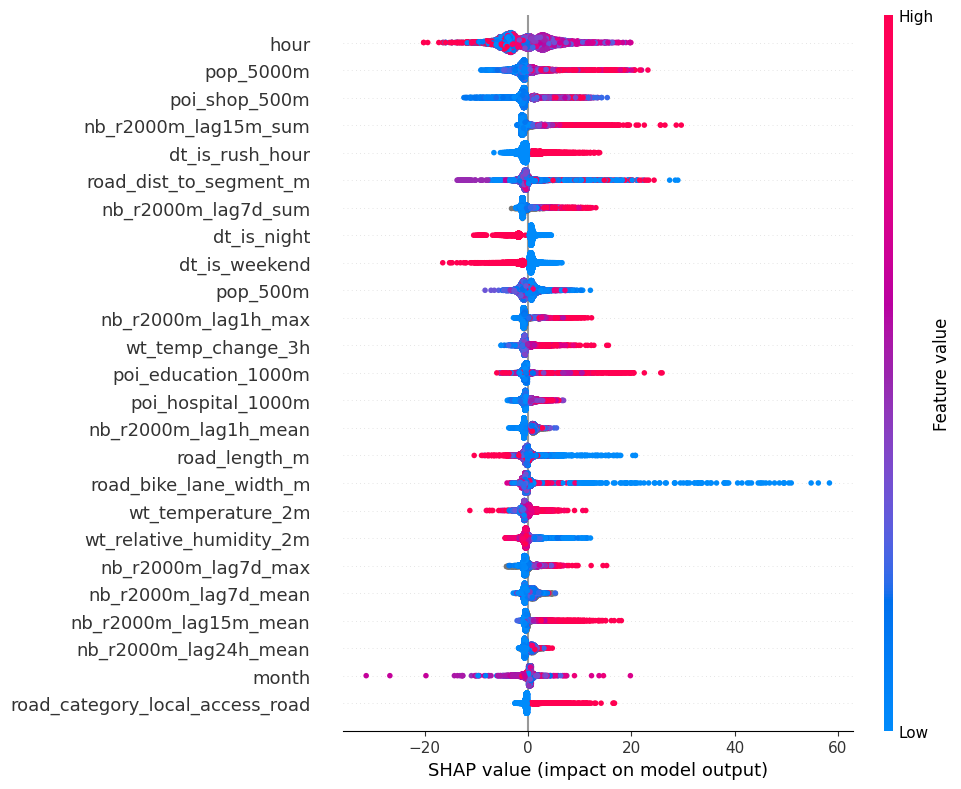

In [51]:
SHAP_SAMPLE = 10000
X_shap = X_train.sample(SHAP_SAMPLE, random_state=42)
print(f"SHAP sample size: {SHAP_SAMPLE:,} % {len(X_train):,} training rows")

explainer    = shap.TreeExplainer(dict_model['LightGBM']['model'])
shap_values  = explainer.shap_values(X_shap)

plt.figure()
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS, max_display=25, show=False, plot_size=(10, 8))

In [52]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
df_shap = (
    pd.DataFrame({"feature": FEATURE_COLS, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
df_shap["rank"]        = df_shap.index + 1
df_shap["cumulative%"] = (df_shap["mean_abs_shap"].cumsum()/ df_shap["mean_abs_shap"].sum() * 100).round(2)
# display(df_shap)

thresholds = sorted(list(range(20, 101, 20))+list(range(90, 101, 2)))
counts = {}
for t in thresholds:
    counts[f"0-{t}"] = (df_shap['cumulative%'] <= t).sum()
_temp = pd.DataFrame(list(counts.items()), columns=["cumulative_bin", "cumulative_nfts"])
_temp['nfts_removed'] = len(FEATURE_COLS) - _temp['cumulative_nfts']
_temp

,cumulative_bin,cumulative_nfts,nfts_removed
0,0-20,3,139
1,0-40,10,132
2,0-60,20,122
3,0-80,36,106
4,0-90,53,89
5,0-92,58,84
6,0-94,64,78
7,0-96,73,69
8,0-98,88,54
9,0-100,142,0


- Out of total 142 features, we only need nearly 1/3 of them (53 features) to explain 90% model. 
- This will reduce model complexity and computing time.
- Next, we will drop 89 features from the original model and keep 54 features with the highest SHAP value.

In [53]:
FEATURE_COLS_SHAP = df_shap[df_shap["cumulative%"] <= 90]['feature'].to_list()
print(len(FEATURE_COLS_SHAP))

X_train_sel = X_train[FEATURE_COLS_SHAP]
X_val_sel = X_val[FEATURE_COLS_SHAP]
X_test_sel = X_test[FEATURE_COLS_SHAP]
print(f"X_train_sel: {X_train_sel.shape} | X_val_sel: {X_val_sel.shape} | X_test_sel : {X_test_sel.shape}")

53
X_train_sel: (1090120, 53) | X_val_sel: (210076, 53) | X_test_sel : (246763, 53)


In [105]:
dict_model.update(
    run_models({"LightGBM_SHAP": LGBMRegressor(**dmodels["LightGBM"].get_params())}, 
    X_train_sel, y_train, X_val_sel, y_val, X_test_sel, y_test)
)

Training models: 100%|██████████| 1/1 [00:17<00:00, 17.66s/it]

LightGBM_SHAP        - Test MAE:    5.873 | Valid MAE:    5.791 | Iter:   999 | nfeatures:   53


In [106]:
pd.DataFrame(dict_model).T

,model,nfeatures,mae,rmse,valid_mae,valid_rmse,time,best_iteration
LinearRegression,LinearRegression(n_jobs=-1),142,11.785121,19.760461,11.149057,19.597597,11.174676,N/A
DecisionTree,"DecisionTreeRegressor(max_depth=10, min_sample...",142,8.347483,16.040404,9.456856,19.345485,37.84986,N/A
RandomForest,"(DecisionTreeRegressor(max_depth=12, max_featu...",142,7.405855,14.469449,8.620639,18.203365,523.698953,N/A
GradientBoosting,([DecisionTreeRegressor(criterion='friedman_ms...,142,8.749457,16.448744,8.737771,16.113269,629.216353,N/A
HistGradientBoosting,"HistGradientBoostingRegressor(max_iter=1000, m...",142,5.65434,11.644422,5.537614,11.010639,135.452396,1000
XGBoost,"XGBRegressor(base_score=None, booster=None, ca...",142,5.951784,12.267893,6.681965,13.625969,85.276146,999
LightGBM,"LGBMRegressor(colsample_bytree=0.8, device='cp...",142,5.799507,11.86212,6.617884,13.434379,44.551212,1000
LightGBM_SHAP,"LGBMRegressor(colsample_bytree=0.8, device='cp...",53,5.873245,12.076413,5.790547,11.773951,17.653749,999


- As expected, cutting of ~1/3 initial number of features helps reducing training from 39.8s to 15.9s, even though the MAE only slightly increase from 5.8 to 5.87, which is not significant.
- Next, we will tune model hypermeter.

### 3.3 Hyperparameters Tuning

In [62]:
param_distributions = {
    'n_estimators': [800, 1000, 1200],
    'learning_rate': [0.01, 0.03, 0.05],
    'num_leaves': [31, 63, 127], 
    'min_child_samples': [50, 100],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 1],  
    'reg_lambda': [0, 0.1, 1],
    'objective': ["regression"],
    'random_state': [42],
    'device': ["cpu"],
    'n_jobs': [-1],
    'verbose': [-1]
}

random_search = RandomizedSearchCV(
    estimator=lgb.LGBMRegressor(),
    param_distributions=param_distributions,
    n_iter=10,                 
    scoring='neg_mean_absolute_error',
    cv=TimeSeriesSplit(n_splits=3),  
    verbose=1,             
    random_state=42,
    n_jobs=1      
)

random_search.fit(X_train_sel, y_train)
print(f"Best Parameters Found: {random_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters Found: {'verbose': -1, 'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'random_state': 42, 'objective': 'regression', 'num_leaves': 63, 'n_jobs': -1, 'n_estimators': 800, 'min_child_samples': 100, 'learning_rate': 0.03, 'device': 'cpu', 'colsample_bytree': 0.7}
Best CV Score (RMAE): 12.3016


In [107]:
dict_model.update(
    run_models({"LightGBM_SHAP_tuned": random_search.best_estimator_}, X_train_sel, y_train, X_val_sel, y_val, X_test_sel, y_test)
)

Training models: 100%|██████████| 1/1 [00:20<00:00, 20.80s/it]

LightGBM_SHAP_tuned  - Test MAE:    5.693 | Valid MAE:    5.637 | Iter:   794 | nfeatures:   53


In [108]:
pd.DataFrame(dict_model).T

,model,nfeatures,mae,rmse,valid_mae,valid_rmse,time,best_iteration
LinearRegression,LinearRegression(n_jobs=-1),142,11.785121,19.760461,11.149057,19.597597,11.174676,N/A
DecisionTree,"DecisionTreeRegressor(max_depth=10, min_sample...",142,8.347483,16.040404,9.456856,19.345485,37.84986,N/A
RandomForest,"(DecisionTreeRegressor(max_depth=12, max_featu...",142,7.405855,14.469449,8.620639,18.203365,523.698953,N/A
GradientBoosting,([DecisionTreeRegressor(criterion='friedman_ms...,142,8.749457,16.448744,8.737771,16.113269,629.216353,N/A
HistGradientBoosting,"HistGradientBoostingRegressor(max_iter=1000, m...",142,5.65434,11.644422,5.537614,11.010639,135.452396,1000
XGBoost,"XGBRegressor(base_score=None, booster=None, ca...",142,5.951784,12.267893,6.681965,13.625969,85.276146,999
LightGBM,"LGBMRegressor(colsample_bytree=0.8, device='cp...",142,5.799507,11.86212,6.617884,13.434379,44.551212,1000
LightGBM_SHAP,"LGBMRegressor(colsample_bytree=0.8, device='cp...",53,5.873245,12.076413,5.790547,11.773951,17.653749,999
LightGBM_SHAP_tuned,"LGBMRegressor(colsample_bytree=0.7, device='cp...",53,5.693091,11.751639,5.636792,11.529118,20.797286,794


- The parameter tunning process has achieved the lowest MAE so far, at `5.693091` and also with the least iteration at `794`.
- Next, we conduct sequential feature selection with both adding and removing features in order to obtain both the less complex model and better MAE score

### 3.3 Feature Selection - Stepwise

In [ ]:
_model     = dict_model['LightGBM_SHAP_tuned']['model']
_params    = _model.get_params()
_lfeatures = _model.feature_name_
print('>>>> Number of features:', len(_lfeatures))

features_rm, dmodel_rm = stepwise_feature_selection_lgb(
    mode='remove',
    list_feature_all=_lfeatures,
    base_model=_model,
    X_train=X_train_sel, 
    y_train=y_train,
    X_valid=X_val_sel, 
    y_valid=y_val,
    model_params=_params
)

>>>> Number of features: 53
Remove: hour                                               | MAE: 6.31517 | current MAE: 5.75132
Remove: pop_5000m                                          | MAE: 5.73589 | current MAE: 5.75132
  => [REMOVED]: pop_5000m                                          | New Base MAE: 5.73589
Remove: poi_shop_500m                                      | MAE: 5.75404 | current MAE: 5.73589
Remove: nb_r2000m_lag15m_sum                               | MAE: 5.74494 | current MAE: 5.73589
Remove: dt_is_rush_hour                                    | MAE: 5.75557 | current MAE: 5.73589
Remove: road_dist_to_segment_m                             | MAE: 5.78416 | current MAE: 5.73589
Remove: nb_r2000m_lag7d_sum                                | MAE: 5.76726 | current MAE: 5.73589
Remove: dt_is_night                                        | MAE: 5.73535 | current MAE: 5.73589
  => [REMOVED]: dt_is_night                                        | New Base MAE: 5.73535
Remove: dt_is_

In [109]:
_model_rm     = dmodel_rm[min(dmodel_rm, key=lambda k: dmodel_rm[k]['MAE'])]['model']
_lfeatures_rm = _model_rm.feature_name_

dict_model.update(
    run_models({"LightGBM_SHAP_tuned_reduced": _model_rm}, 
    X_train[_lfeatures_rm], y_train, X_val[_lfeatures_rm], y_val, X_test[_lfeatures_rm], y_test)
)

Training models: 100%|██████████| 1/1 [00:18<00:00, 18.31s/it]

LightGBM_SHAP_tuned_reduced - Test MAE:    5.684 | Valid MAE:    5.477 | Iter:   800 | nfeatures:   44


- After remove sequential 9 features (from `LightGBM_SHAP_tuned` with 53 features to 44 features), the model's MAE decrease from `6.31517` to `5.59638` in evaluating the valid set.
- We then evaluated the test set and also obtain slightly lower MAE from `5.683754` to `5.693091` for this removed feature model `LightGBM_SHAP_tuned_reduced`. This is also the lowest MAE model so far.

In [45]:
print('>>>> Current number of features:', len(_lfeatures_rm))

features_add, dmodel_add = stepwise_feature_selection_lgb(
    mode='add',
    list_feature_all=_lfeatures,
    base_model=_model_rm,
    X_train=X_train, 
    y_train=y_train,
    X_valid=X_val, 
    y_valid=y_val,
    model_params=_model_rm.get_params()
)

>>>> Current number of features: 44
Add: pop_5000m                                          | MAE: 5.60901 | current MAE: 5.59638
Add: dt_is_night                                        | MAE: 5.61941 | current MAE: 5.59638
Add: wt_relative_humidity_2m                            | MAE: 5.68216 | current MAE: 5.59638
Add: nb_r2000m_lag7d_max                                | MAE: 5.64453 | current MAE: 5.59638
Add: wt_pressure_msl                                    | MAE: 5.70017 | current MAE: 5.59638
Add: wt_cloud_cover                                     | MAE: 5.61415 | current MAE: 5.59638
Add: nb_r1000m_lag1h_sum                                | MAE: 5.63807 | current MAE: 5.59638
Add: nb_r1000m_lag7d_mean                               | MAE: 5.61258 | current MAE: 5.59638
Add: nb_r200m_lag1h_mean                                | MAE: 5.61952 | current MAE: 5.59638


In [111]:
pd.DataFrame(dict_model).T

,model,nfeatures,mae,rmse,valid_mae,valid_rmse,time,best_iteration
LinearRegression,LinearRegression(n_jobs=-1),142,11.785121,19.760461,11.149057,19.597597,11.174676,N/A
DecisionTree,"DecisionTreeRegressor(max_depth=10, min_sample...",142,8.347483,16.040404,9.456856,19.345485,37.84986,N/A
RandomForest,"(DecisionTreeRegressor(max_depth=12, max_featu...",142,7.405855,14.469449,8.620639,18.203365,523.698953,N/A
GradientBoosting,([DecisionTreeRegressor(criterion='friedman_ms...,142,8.749457,16.448744,8.737771,16.113269,629.216353,N/A
HistGradientBoosting,"HistGradientBoostingRegressor(max_iter=1000, m...",142,5.65434,11.644422,5.537614,11.010639,135.452396,1000
XGBoost,"XGBRegressor(base_score=None, booster=None, ca...",142,5.951784,12.267893,6.681965,13.625969,85.276146,999
LightGBM,"LGBMRegressor(colsample_bytree=0.8, device='cp...",142,5.799507,11.86212,6.617884,13.434379,44.551212,1000
LightGBM_SHAP,"LGBMRegressor(colsample_bytree=0.8, device='cp...",53,5.873245,12.076413,5.790547,11.773951,17.653749,999
LightGBM_SHAP_tuned,"LGBMRegressor(colsample_bytree=0.7, device='cp...",53,5.693091,11.751639,5.636792,11.529118,20.797286,794
LightGBM_SHAP_tuned_reduced,"LGBMRegressor(colsample_bytree=0.7, device='cp...",44,5.683754,11.702608,5.476652,11.091659,18.309222,800


- After sequentially adding 8 features we removed from previous step, no added feature can help improve MAE.
- Hence, our **finalmodel ** (`LightGBM_SHAP_tuned_reduced`) has 44 features and obtain the lowest `MAE = 5.683754` for `test set` and `MAE = 5.59638` for valid set 

In [112]:
pd.to_pickle(dict_model,'dmodel_final.pickle')
pd.to_pickle(dict_model['LightGBM_SHAP_tuned_reduced']['model'],'model_final.pickle')

### 3.4 Interpretation of final model

SHAP sample size: 10,000 % 1,546,959 training rows


Text(0.5, 1.0, 'SHAP Analysis — LightGBM_SHAP_tuned_reduced (44 features)')

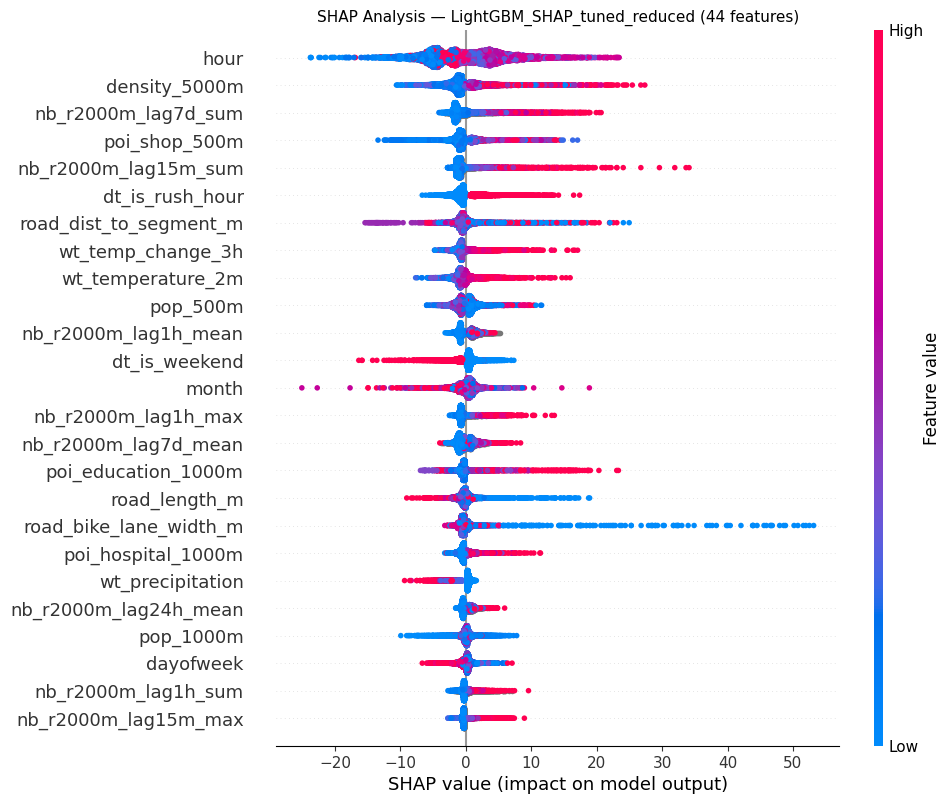

In [ ]:
final_model = pd.read_pickle('model_final.pickle')
final_features = final_model.feature_name_ 

SHAP_SAMPLE = 10000
X_train_final = X_train[X_train['tvt'] == 'train'][final_features]
X_SHAP_final = X_train_final.sample(n=SHAP_SAMPLE, random_state=42)
print(f"SHAP sample size: {SHAP_SAMPLE:,} % {len(X_train):,} training rows")

explainer_final   = shap.TreeExplainer(final_model)
shap_values_final = explainer_final.shap_values(X_SHAP_final)

plt.figure()
shap.summary_plot(shap_values_final,X_SHAP_final,feature_names=final_features,max_display=25,show=False,plot_size=(10, 8),)
plt.title("SHAP Analysis — LightGBM_SHAP_tuned_reduced (44 features)", fontsize=11)
# plt.tight_layout()
# plt.savefig("shap_final.png", dpi=150, bbox_inches="tight")
# plt.show()